# 01 — Exploratory Data Analysis

**Project:** Robust Biometric Signature Verification Against Skilled Forgeries

Covers all five corpora (CEDAR, BHSig260 Bengali/Hindi, GPDS Synthetic 4000,
institutional `signature_verification`):

1. Dataset distribution — genuine vs. forgery counts, per-writer balance
2. Image metadata & quality — dimensions, aspect ratios, channels, corrupted files
3. Visual inspection — random sample grids, genuine-vs-forgery side-by-side
4. Pixel intensity & contrast — class-conditional intensity histograms

**Conventions**
- Writer identity = **folder ID** (guards the BHSig260-Hindi writer-123
  filename anomaly); filename IDs are cross-checked and mismatches reported.
- GPDS `ParamsUserNNNN.mat` metadata files are ignored.
- Raw data is never modified. Figures → `report/figures/eda/`,
  tables → `report/dataset_checks/`.

In [14]:
from __future__ import annotations

import random
from collections import defaultdict
from pathlib import Path
from typing import Iterable, Optional

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from PIL import Image, UnidentifiedImageError

from sigver.data.catalog import build_catalog

sns.set_theme(style="whitegrid", context="notebook")
RNG_SEED = 42
random.seed(RNG_SEED)
np.random.seed(RNG_SEED)

# Resolve project root dynamically: works from notebooks/ or the repo root.
_here = Path.cwd()
PROJECT_ROOT = _here if (_here / "data" / "raw").is_dir() else _here.parent
assert (PROJECT_ROOT / "data" / "raw").is_dir(), (
    f"Could not locate data/raw relative to {_here}. "
    "Run from the project root or the notebooks/ folder."
)

RAW_ROOT = PROJECT_ROOT / "data" / "raw"
FIG_DIR = PROJECT_ROOT / "report" / "figures" / "eda"
TABLE_DIR = PROJECT_ROOT / "report" / "dataset_checks"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

# Metadata scanning: full scan of ~400k images is slow on a laptop. Set to
# None for a full scan (recommended once, before preprocessing is frozen);
# an integer caps the per-dataset sample for fast iteration.
METADATA_SAMPLE_PER_DATASET: Optional[int] = None

print(f"Project root : {PROJECT_ROOT}")
print(f"Figure output: {FIG_DIR}")


def savefig(fig: plt.Figure, name: str) -> None:
    """Save a figure to report/figures/eda/<name>.png at print quality."""
    out = FIG_DIR / f"{name}.png"
    fig.savefig(out, dpi=150, bbox_inches="tight")
    print(f"  saved -> {out.relative_to(PROJECT_ROOT)}")

Project root : c:\Users\nehas\Downloads\robust-signature-verification
Figure output: c:\Users\nehas\Downloads\robust-signature-verification\report\figures\eda


In [15]:
catalog = build_catalog(RAW_ROOT)
print(f"Indexed {len(catalog):,} files across {catalog['dataset'].nunique()} datasets")

# Files whose names did not parse: report, then exclude from analysis.
unrecognized = catalog[catalog["label"].isna()]
if not unrecognized.empty:
    print(f"WARNING: {len(unrecognized)} unrecognized files (excluded from EDA):")
    print(unrecognized[["dataset", "path"]].head(20).to_string(index=False))
    unrecognized.to_csv(TABLE_DIR / "eda_unrecognized_files.csv", index=False)

# Filename-vs-folder ID cross-check (expected: BHSig260-Hindi writer 123).
mismatches = catalog[catalog["id_mismatch"] | catalog["label_mismatch"]]
if not mismatches.empty:
    print(f"NOTE: {len(mismatches)} filename/folder inconsistencies "
          "(folder ID is treated as ground truth):")
    print(
        mismatches.groupby(["dataset", "writer_id"], observed=True)
        .size()
        .to_string()
    )
    mismatches.to_csv(TABLE_DIR / "eda_id_mismatches.csv", index=False)

df = catalog.dropna(subset=["label"]).copy()
df.head()

Indexed 344,680 files across 5 datasets
NOTE: 24 filename/folder inconsistencies (folder ID is treated as ground truth):
dataset         writer_id
bhsig260_hindi  123          24


,dataset,writer_id,label,path,filename,ext,filename_writer_id,id_mismatch,label_mismatch
0,cedar,1,forgery,c:\Users\nehas\Downloads\robust-signature-veri...,forgeries_1_1.png,.png,1,False,False
1,cedar,1,forgery,c:\Users\nehas\Downloads\robust-signature-veri...,forgeries_1_10.png,.png,1,False,False
2,cedar,1,forgery,c:\Users\nehas\Downloads\robust-signature-veri...,forgeries_1_11.png,.png,1,False,False
3,cedar,1,forgery,c:\Users\nehas\Downloads\robust-signature-veri...,forgeries_1_12.png,.png,1,False,False
4,cedar,1,forgery,c:\Users\nehas\Downloads\robust-signature-veri...,forgeries_1_13.png,.png,1,False,False


## 1. Dataset distribution analysis


label                forgery  genuine   total  forgery_ratio
dataset                                                     
bhsig260_bengali        3000     2400    5400          0.556
bhsig260_hindi          4800     3840    8640          0.556
cedar                   1320     1320    2640          0.500
gpds_synthetic_4000   120000    96000  216000          0.556
institutional          64000    48000  112000          0.571
  saved -> report\figures\eda\class_distribution_per_dataset.png


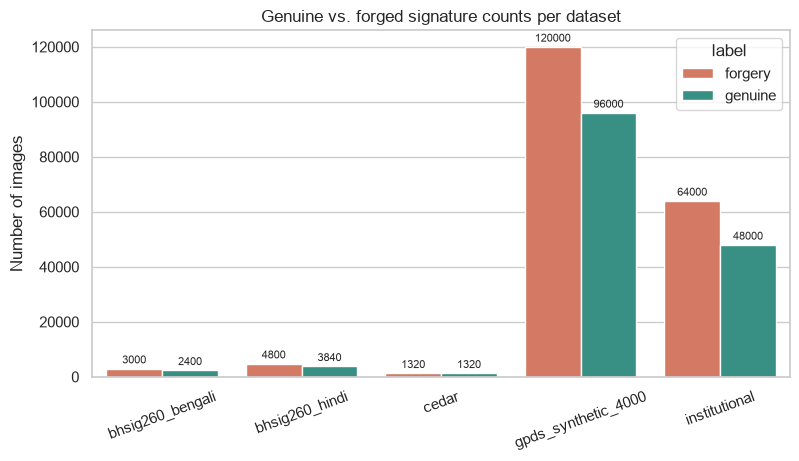

In [16]:
class_counts = (
    df.groupby(["dataset", "label"], observed=True)
    .size()
    .rename("n_images")
    .reset_index()
)
class_counts_wide = class_counts.pivot(
    index="dataset", columns="label", values="n_images"
).fillna(0).astype(int)
class_counts_wide["total"] = class_counts_wide.sum(axis=1)
class_counts_wide["forgery_ratio"] = (
    class_counts_wide.get("forgery", 0) / class_counts_wide["total"]
).round(3)
class_counts_wide.to_csv(TABLE_DIR / "eda_class_counts.csv")
print(class_counts_wide)

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.barplot(
    data=class_counts, x="dataset", y="n_images", hue="label",
    palette={"genuine": "#2a9d8f", "forgery": "#e76f51"}, ax=ax,
)
ax.set_title("Genuine vs. forged signature counts per dataset")
ax.set_xlabel("")
ax.set_ylabel("Number of images")
ax.tick_params(axis="x", rotation=20)
for container in ax.containers:
    ax.bar_label(container, fmt="%d", fontsize=8, padding=2)
savefig(fig, "class_distribution_per_dataset")
plt.show()

Per-writer sample counts (modal / min / max):
                             modal_count  min  max  n_writers
dataset             label                                    
bhsig260_bengali    forgery           30   30   30        100
                    genuine           24   24   24        100
bhsig260_hindi      forgery           30   30   30        160
                    genuine           24   24   24        160
cedar               forgery           24   24   24         55
                    genuine           24   24   24         55
gpds_synthetic_4000 forgery           30   30   30       4000
                    genuine           24   24   24       4000
institutional       forgery           16   16   16       4000
                    genuine           12   12   12       4000

All writers match the modal counts — no per-writer imbalance.
  saved -> report\figures\eda\per_writer_counts.png


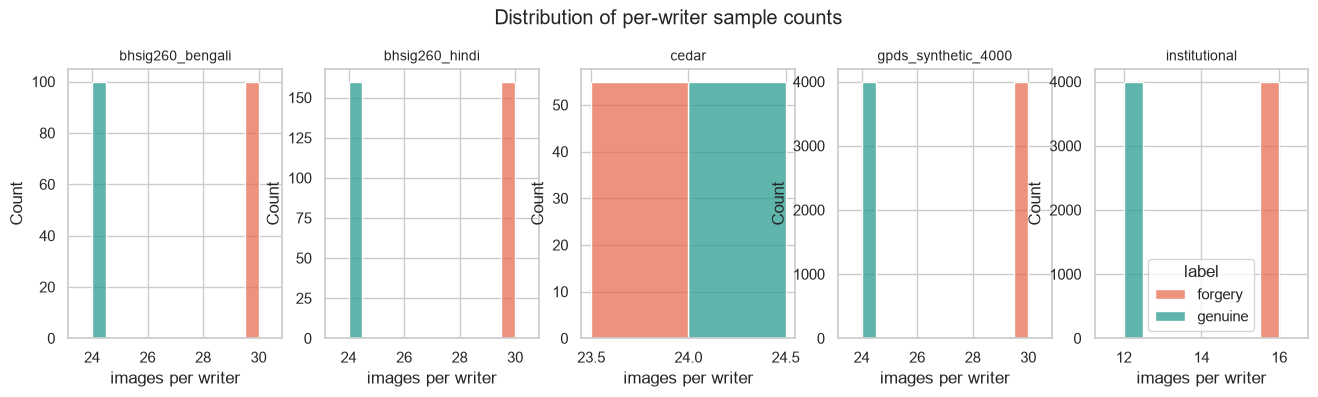

In [17]:
per_writer = (
    df.groupby(["dataset", "writer_id", "label"], observed=True)
    .size()
    .rename("n")
    .reset_index()
)

# Modal genuine/forgery count per dataset, plus deviating writers.
modal = (
    per_writer.groupby(["dataset", "label"], observed=True)["n"]
    .agg(modal_count=lambda s: s.mode().iat[0], min="min", max="max",
         n_writers="count")
)
print("Per-writer sample counts (modal / min / max):")
print(modal)
modal.to_csv(TABLE_DIR / "eda_per_writer_modal_counts.csv")

deviants = per_writer.merge(
    modal["modal_count"].reset_index(), on=["dataset", "label"]
)
deviants = deviants[deviants["n"] != deviants["modal_count"]]
if deviants.empty:
    print("\nAll writers match the modal counts — no per-writer imbalance.")
else:
    print(f"\n{len(deviants)} writer/label groups deviate from modal counts:")
    print(deviants.to_string(index=False))
    deviants.to_csv(TABLE_DIR / "eda_per_writer_deviations.csv", index=False)

fig, axes = plt.subplots(
    1, df["dataset"].nunique(), figsize=(16, 3.5), sharey=False
)
for ax, (ds, grp) in zip(
    np.atleast_1d(axes), per_writer.groupby("dataset", observed=True)
):
    sns.histplot(
        data=grp, x="n", hue="label", multiple="dodge", discrete=True,
        palette={"genuine": "#2a9d8f", "forgery": "#e76f51"},
        ax=ax, legend=(ax is np.atleast_1d(axes)[-1]),
    )
    ax.set_title(ds, fontsize=10)
    ax.set_xlabel("images per writer")
fig.suptitle("Distribution of per-writer sample counts", y=1.05)
savefig(fig, "per_writer_counts")
plt.show()

## 2. Image metadata & quality analysis

Dimensions/mode are read from image headers (fast, no full decode).
Corruption is checked with a header `verify()` pass plus a full decode on
the sampled subset. Set `METADATA_SAMPLE_PER_DATASET = None` for one full
pass over every image before you freeze the preprocessing pipeline.

In [18]:
def scan_image_metadata(
    paths: Iterable[str],
    full_decode: bool = True,
) -> pd.DataFrame:
    """Read width/height/mode for each image; flag unreadable files.

    Args:
        paths: Image file paths.
        full_decode: If True, also force a full pixel decode (catches
            truncated files that pass the header check).

    Returns:
        DataFrame with columns path, width, height, mode, n_channels,
        aspect_ratio, corrupt, error.
    """
    records: list[dict] = []
    mode_channels = {"1": 1, "L": 1, "P": 1, "I": 1, "F": 1,
                     "LA": 2, "RGB": 3, "YCbCr": 3, "RGBA": 4, "CMYK": 4}
    for p in paths:
        rec: dict = {"path": p, "width": None, "height": None, "mode": None,
                     "n_channels": None, "aspect_ratio": None,
                     "corrupt": False, "error": ""}
        try:
            with Image.open(p) as im:
                rec["width"], rec["height"] = im.size
                rec["mode"] = im.mode
                rec["n_channels"] = mode_channels.get(im.mode)
                rec["aspect_ratio"] = round(im.size[0] / im.size[1], 4)
                im.verify()  # header/CRC-level integrity check
            if full_decode:
                with Image.open(p) as im:
                    im.load()  # full decode: catches truncated payloads
        except (UnidentifiedImageError, OSError, SyntaxError, ValueError) as e:
            rec["corrupt"] = True
            rec["error"] = f"{type(e).__name__}: {e}"
        records.append(rec)
    return pd.DataFrame(records)


def sample_paths(frame: pd.DataFrame, per_dataset: Optional[int]) -> pd.DataFrame:
    """Stratified sample of catalog rows: up to `per_dataset` rows per dataset.

    Implemented with explicit concat (not groupby().apply) so the grouping
    column survives across pandas versions.
    """
    if per_dataset is None:
        return frame
    parts = [
        g.sample(min(len(g), per_dataset), random_state=RNG_SEED)
        for _, g in frame.groupby("dataset", observed=True)
    ]
    return pd.concat(parts)


meta_sample = sample_paths(df, METADATA_SAMPLE_PER_DATASET)
print(f"Scanning metadata for {len(meta_sample):,} images "
      f"(sample cap per dataset: {METADATA_SAMPLE_PER_DATASET})")
meta = scan_image_metadata(meta_sample["path"])
meta = meta_sample[["dataset", "writer_id", "label", "path"]].merge(meta, on="path")

corrupt = meta[meta["corrupt"]]
if corrupt.empty:
    print("No corrupted/unreadable images found in the scanned subset.")
else:
    print(f"WARNING: {len(corrupt)} corrupted images found:")
    print(corrupt[["dataset", "path", "error"]].to_string(index=False))
    corrupt.to_csv(TABLE_DIR / "eda_corrupted_images.csv", index=False)

# Zero/near-empty content check: images whose decoded pixels are constant.
def flag_empty_images(paths: Iterable[str]) -> list[str]:
    """Return paths whose decoded grayscale content has ~zero variance."""
    empty: list[str] = []
    for p in paths:
        img = cv2.imread(str(p), cv2.IMREAD_GRAYSCALE)
        if img is None or img.std() < 1.0:
            empty.append(p)
    return empty

# Cheap spot-check on a smaller sub-sample (full pass is O(dataset size)).
ok_paths = meta.loc[~meta["corrupt"], "path"]
spot = ok_paths.sample(min(500, len(ok_paths)), random_state=RNG_SEED)
empty_paths = flag_empty_images(spot)
print(f"Near-empty images in {len(spot)}-image spot check: {len(empty_paths)}")
if empty_paths:
    pd.Series(empty_paths, name="path").to_csv(
        TABLE_DIR / "eda_empty_images.csv", index=False
    )

Scanning metadata for 344,680 images (sample cap per dataset: None)
No corrupted/unreadable images found in the scanned subset.
Near-empty images in 500-image spot check: 0


                          n  width_min  width_med  width_max  height_min  height_med  height_max   ar_med                                modes
dataset                                                                                                                                       
bhsig260_bengali       5400        898      992.0       1083         233       279.0         305  3.43970               {'L': 4292, 'P': 1108}
bhsig260_hindi         8640        843      979.0       1329         229       283.0         435  3.46450               {'L': 4383, 'P': 4257}
cedar                  2640        264      576.0        888         145       342.0         816  1.52345  {'P': 1248, 'L': 1248, 'RGBA': 144}
gpds_synthetic_4000  216000        263      951.0       2973         216       588.0        1338  1.63810                        {'L': 216000}
institutional        112000        220      220.0        220         155       155.0         155  1.41940                      {'RGB': 112000}

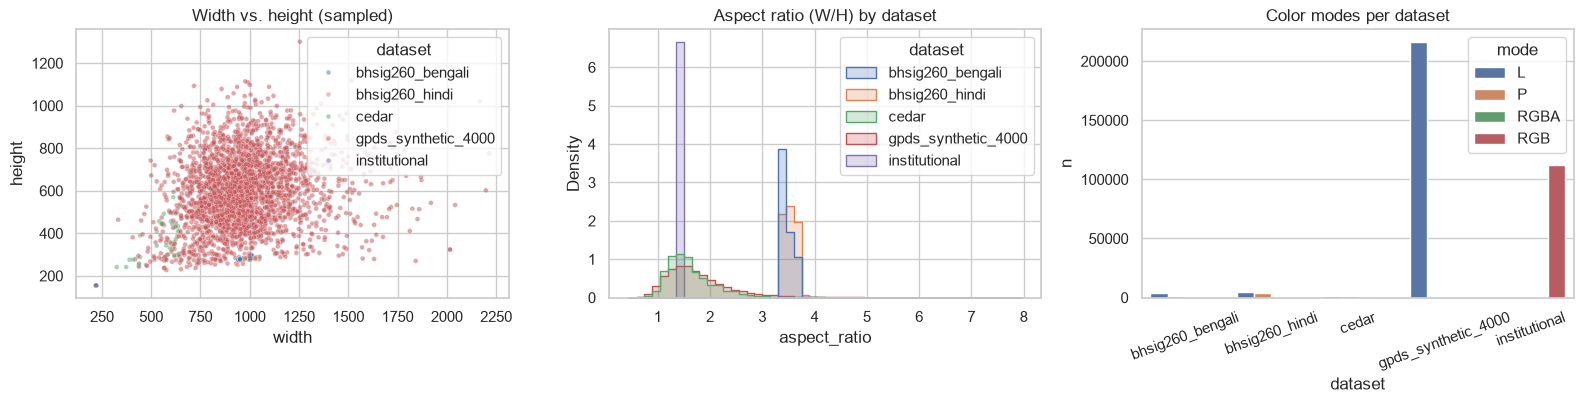


Aspect-ratio quantiles (5% / 50% / 95%) — use to choose the padded canvas aspect before resizing:
                     0.05  0.50  0.95
dataset                              
bhsig260_bengali     3.39  3.44  3.63
bhsig260_hindi       3.42  3.46  3.66
cedar                1.08  1.52  2.54
gpds_synthetic_4000  1.01  1.64  2.99
institutional        1.42  1.42  1.42


In [19]:
ok = meta[~meta["corrupt"]].copy()

summary = (
    ok.groupby("dataset", observed=True)
    .agg(
        n=("path", "count"),
        width_min=("width", "min"), width_med=("width", "median"),
        width_max=("width", "max"),
        height_min=("height", "min"), height_med=("height", "median"),
        height_max=("height", "max"),
        ar_med=("aspect_ratio", "median"),
        modes=("mode", lambda s: dict(s.value_counts())),
    )
)
print(summary.to_string())
summary.to_csv(TABLE_DIR / "eda_dimension_summary.csv")

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
sns.scatterplot(
    data=ok.sample(min(len(ok), 4000), random_state=RNG_SEED),
    x="width", y="height", hue="dataset", s=12, alpha=0.5, ax=axes[0],
)
axes[0].set_title("Width vs. height (sampled)")
sns.histplot(data=ok, x="aspect_ratio", hue="dataset", element="step",
             stat="density", common_norm=False, bins=50, ax=axes[1])
axes[1].set_title("Aspect ratio (W/H) by dataset")
mode_counts = (
    ok.groupby(["dataset", "mode"], observed=True).size().rename("n").reset_index()
)
sns.barplot(data=mode_counts, x="dataset", y="n", hue="mode", ax=axes[2])
axes[2].set_title("Color modes per dataset")
axes[2].tick_params(axis="x", rotation=20)
fig.tight_layout()
savefig(fig, "image_dimensions_overview")
plt.show()

# Resizing guidance: aspect-ratio quantiles inform the canonical input shape
# (pad-to-aspect then resize preserves stroke geometry better than warping).
ar_q = ok.groupby("dataset", observed=True)["aspect_ratio"].quantile(
    [0.05, 0.5, 0.95]
).unstack()
print("\nAspect-ratio quantiles (5% / 50% / 95%) — use to choose the padded "
      "canvas aspect before resizing:")
print(ar_q.round(2))

## 3. Visual data inspection

  saved -> report\figures\eda\sample_grid_all.png


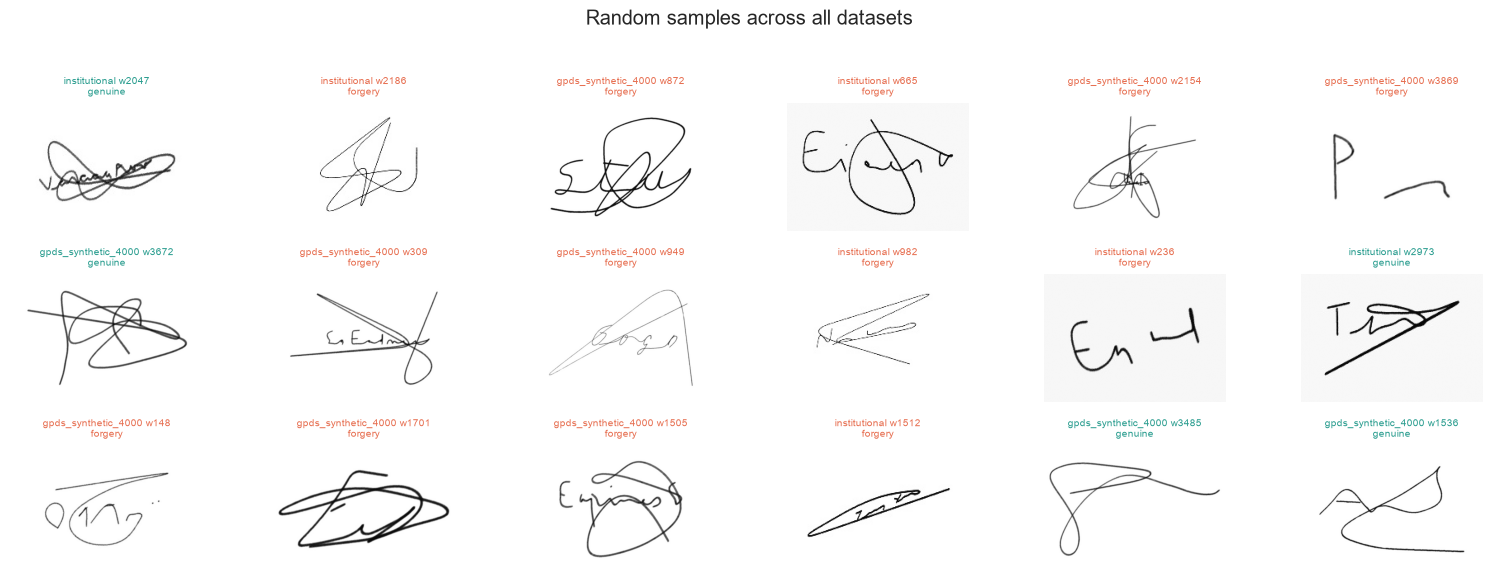

  saved -> report\figures\eda\sample_grid_bhsig260_bengali.png


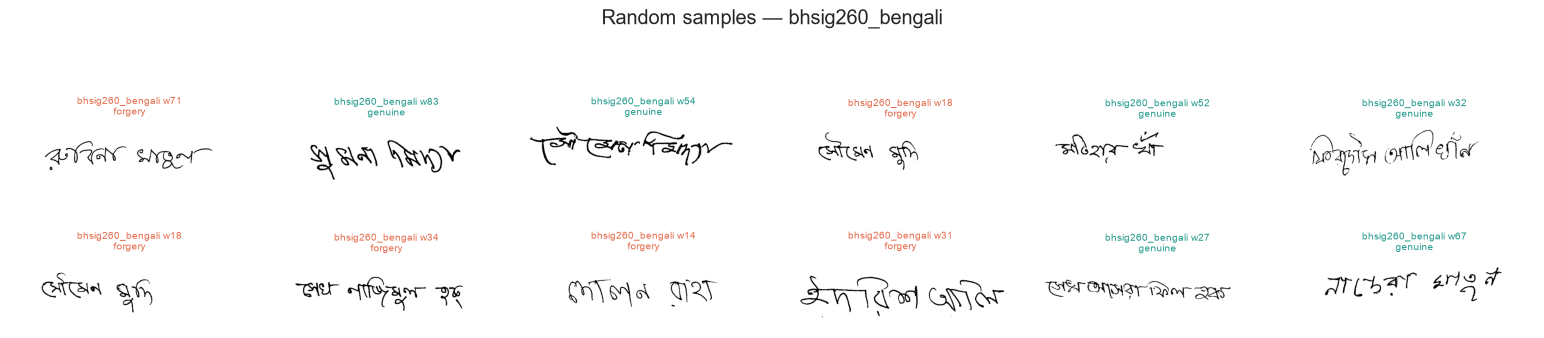

  saved -> report\figures\eda\sample_grid_bhsig260_hindi.png


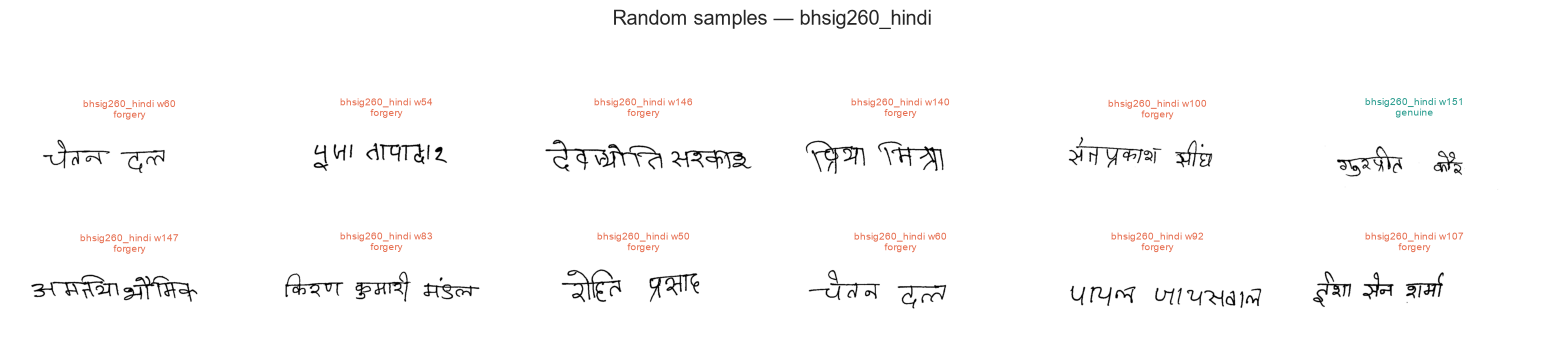

  saved -> report\figures\eda\sample_grid_cedar.png


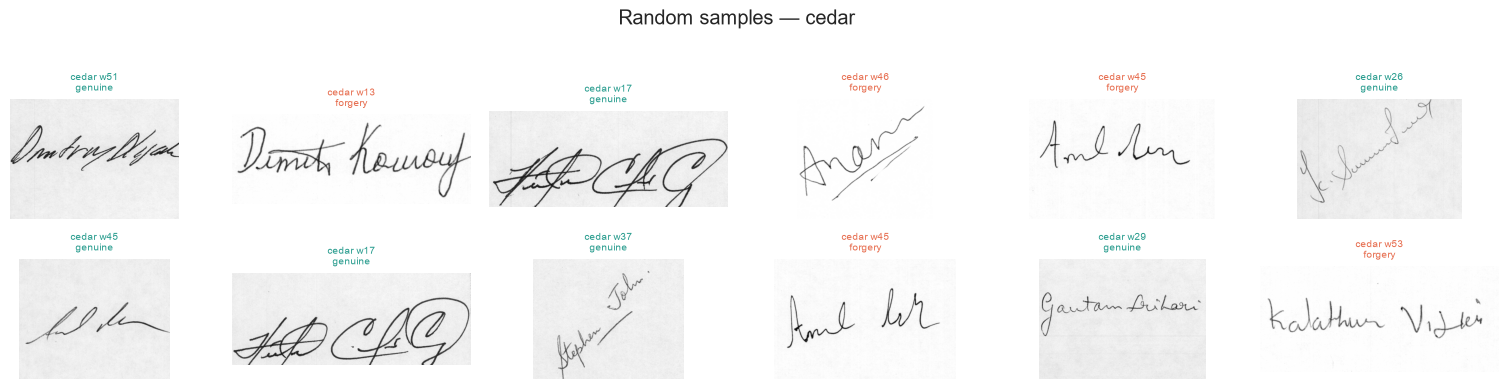

  saved -> report\figures\eda\sample_grid_gpds_synthetic_4000.png


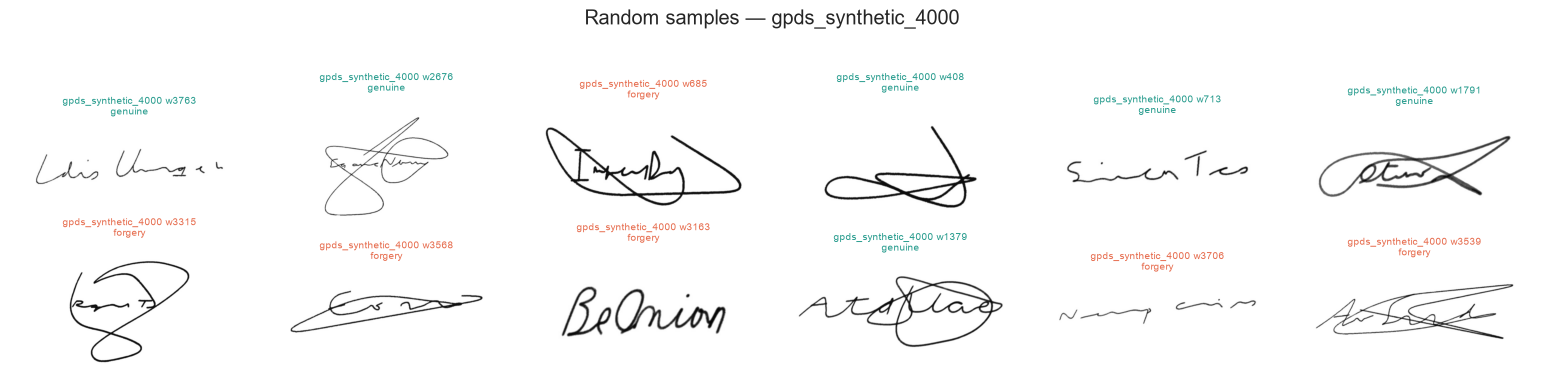

  saved -> report\figures\eda\sample_grid_institutional.png


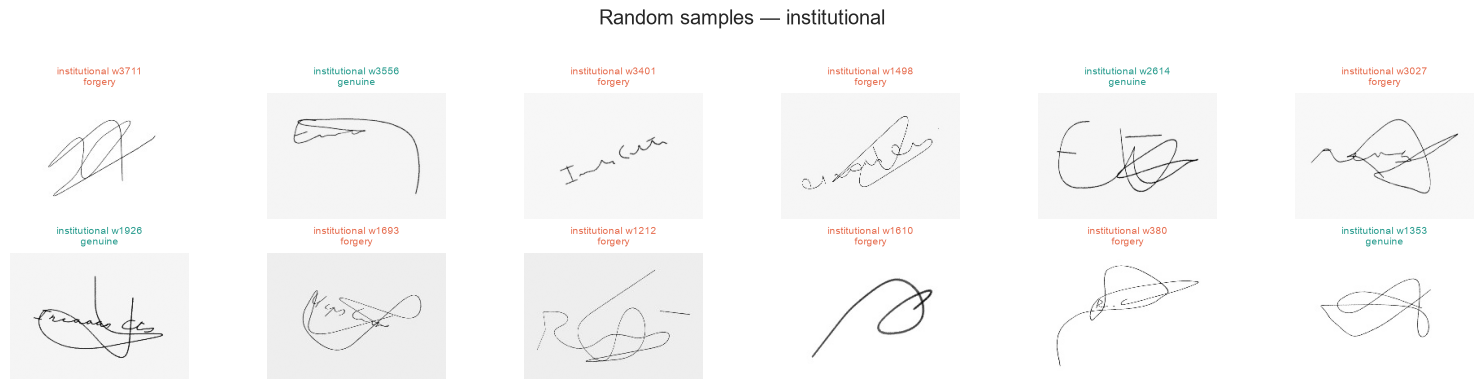

In [20]:
def load_gray(path: str) -> Optional[np.ndarray]:
    """Load an image as grayscale uint8, or None on failure."""
    img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    return img


def plot_sample_grid(
    frame: pd.DataFrame,
    n_rows: int = 3,
    n_cols: int = 6,
    title: str = "Random signature samples",
    fname: Optional[str] = None,
) -> None:
    """Plot a grid of random samples labeled dataset / writer / class."""
    sample = frame.sample(min(n_rows * n_cols, len(frame)), random_state=None)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(2.6 * n_cols, 1.9 * n_rows))
    for ax, (_, row) in zip(axes.flat, sample.iterrows()):
        img = load_gray(row["path"])
        if img is None:
            ax.set_title("unreadable", fontsize=7)
        else:
            ax.imshow(img, cmap="gray")
            color = "#2a9d8f" if row["label"] == "genuine" else "#e76f51"
            ax.set_title(
                f"{row['dataset']} w{row['writer_id']}\n{row['label']}",
                fontsize=7, color=color,
            )
        ax.axis("off")
    for ax in axes.flat[len(sample):]:
        ax.axis("off")
    fig.suptitle(title, y=1.02)
    fig.tight_layout()
    if fname:
        savefig(fig, fname)
    plt.show()


plot_sample_grid(df, title="Random samples across all datasets",
                 fname="sample_grid_all")

# One grid per dataset — scan for background artifacts, scanner borders, etc.
for ds, grp in df.groupby("dataset", observed=True):
    plot_sample_grid(grp, n_rows=2, n_cols=6,
                     title=f"Random samples — {ds}",
                     fname=f"sample_grid_{ds}")

  saved -> report\figures\eda\genuine_vs_forgery_bhsig260_bengali_w82.png


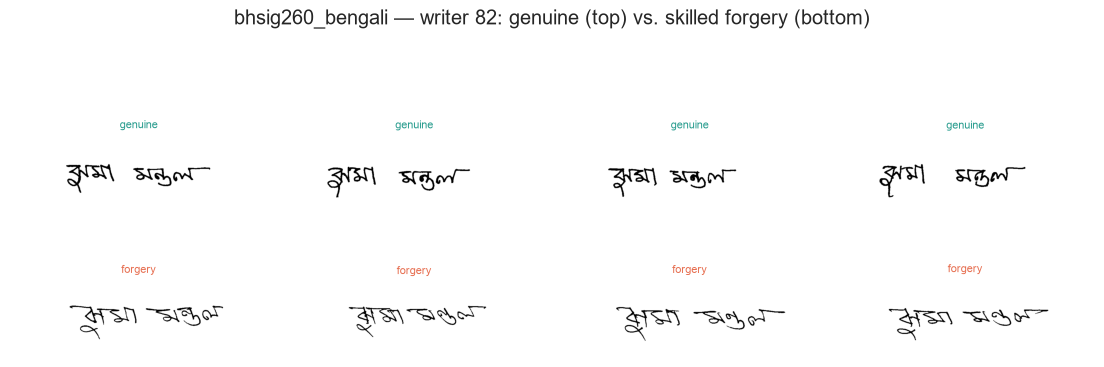

  saved -> report\figures\eda\genuine_vs_forgery_bhsig260_hindi_w124.png


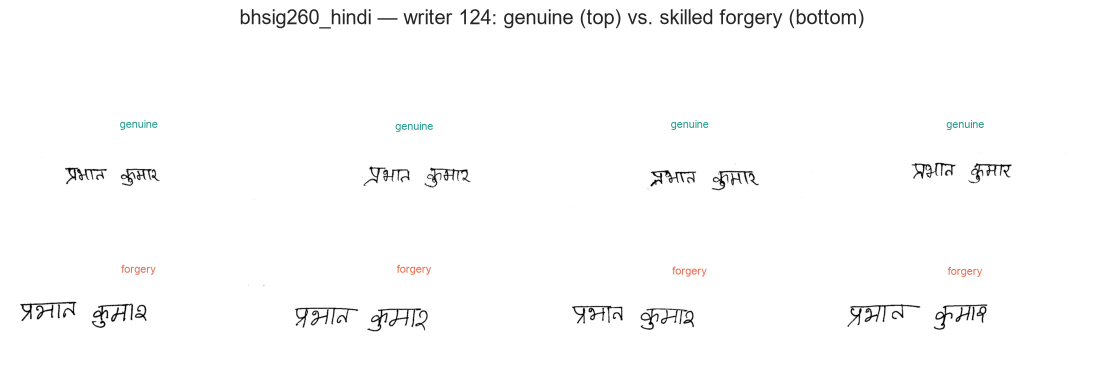

  saved -> report\figures\eda\genuine_vs_forgery_cedar_w10.png


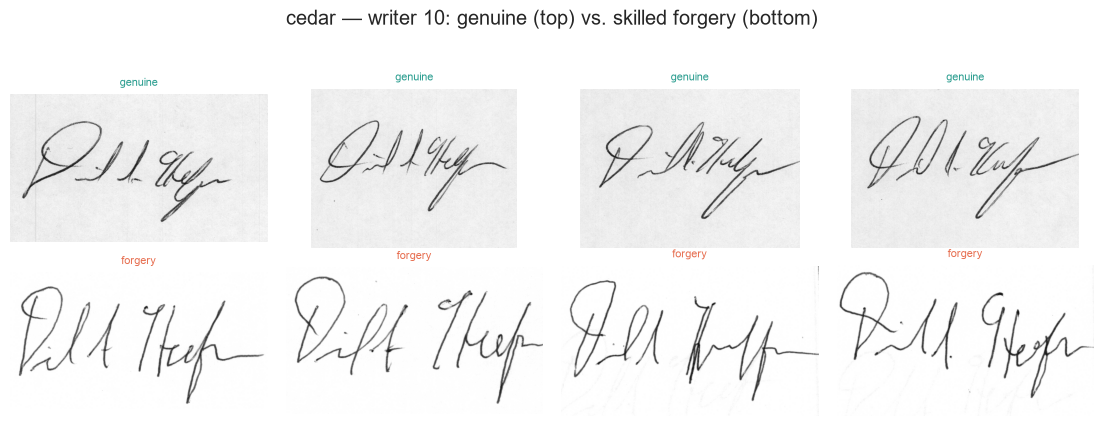

  saved -> report\figures\eda\genuine_vs_forgery_gpds_synthetic_4000_w3732.png


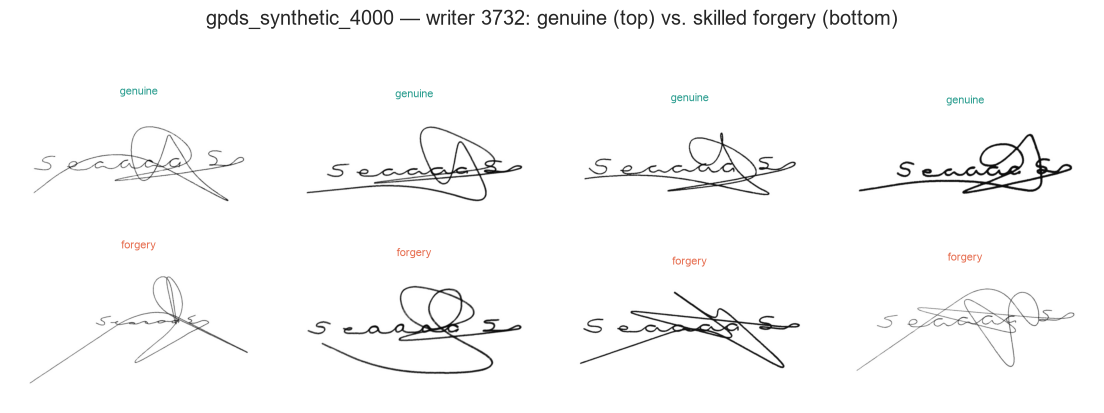

  saved -> report\figures\eda\genuine_vs_forgery_institutional_w2011.png


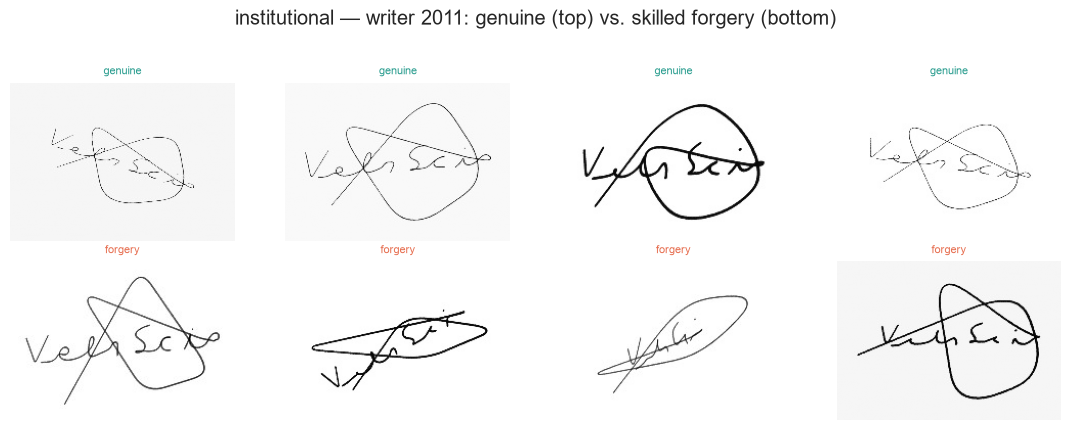

In [21]:
def plot_genuine_vs_forgery(
    frame: pd.DataFrame,
    dataset: str,
    writer_id: Optional[str] = None,
    n_pairs: int = 4,
) -> None:
    """Side-by-side genuine (top) vs. forged (bottom) samples for one writer.

    This is the core visual for the verification task: the model must
    separate exactly these pairs. If `writer_id` is None a random writer
    with both classes present is chosen.
    """
    ds = frame[frame["dataset"] == dataset]
    writers_with_both = (
        ds.groupby("writer_id", observed=True)["label"].nunique()
    )
    candidates = writers_with_both[writers_with_both == 2].index
    if len(candidates) == 0:
        print(f"[{dataset}] no writer has both classes — skipping.")
        return
    if writer_id is None or writer_id not in set(candidates):
        writer_id = random.choice(list(candidates))
    w = ds[ds["writer_id"] == writer_id]
    gen = w[w["label"] == "genuine"].sample(
        min(n_pairs, (w["label"] == "genuine").sum()), random_state=RNG_SEED)
    forg = w[w["label"] == "forgery"].sample(
        min(n_pairs, (w["label"] == "forgery").sum()), random_state=RNG_SEED)

    fig, axes = plt.subplots(2, n_pairs, figsize=(2.8 * n_pairs, 4.2))
    for col in range(n_pairs):
        for row_i, (subset, tag, color) in enumerate(
            [(gen, "genuine", "#2a9d8f"), (forg, "forgery", "#e76f51")]
        ):
            ax = axes[row_i, col]
            if col < len(subset):
                img = load_gray(subset.iloc[col]["path"])
                if img is not None:
                    ax.imshow(img, cmap="gray")
                ax.set_title(tag, fontsize=8, color=color)
            ax.axis("off")
    fig.suptitle(f"{dataset} — writer {writer_id}: genuine (top) vs. "
                 f"skilled forgery (bottom)", y=1.02)
    fig.tight_layout()
    savefig(fig, f"genuine_vs_forgery_{dataset}_w{writer_id}")
    plt.show()


for ds in df["dataset"].cat.categories:
    plot_genuine_vs_forgery(df, ds)

## 4. Pixel intensity & contrast analysis

Class-conditional intensity histograms reveal whether genuine and forged
scans differ in background/ink statistics. **Interpretation caveat:** if
the two classes have systematically different intensity profiles within a
dataset, that is a potential acquisition artifact the network could
exploit as a shortcut — a preprocessing (binarization/normalization)
argument, not a legitimate discriminative feature.

  saved -> report\figures\eda\intensity_histograms_per_class.png


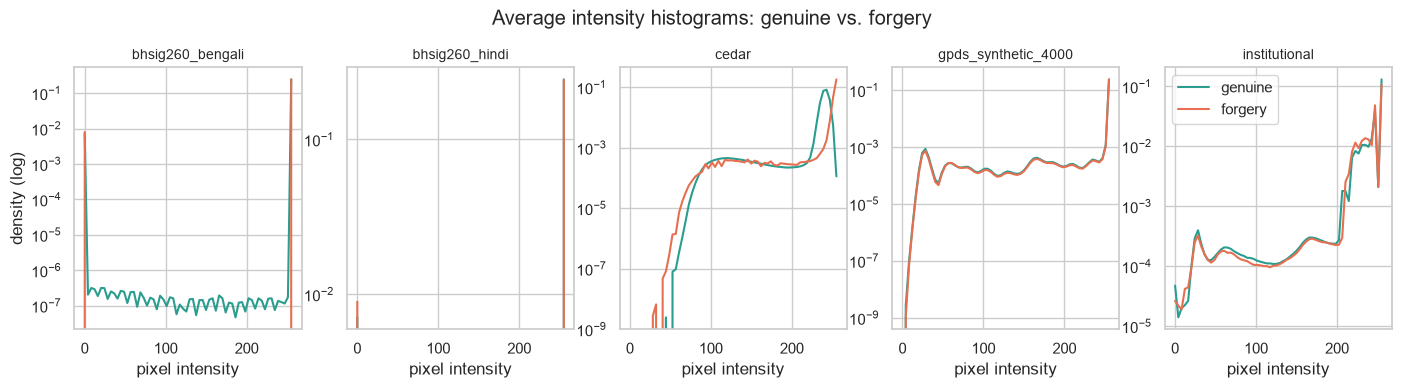

In [22]:
def compute_intensity_stats(
    frame: pd.DataFrame,
    per_group: int = 300,
    bins: int = 64,
) -> tuple[pd.DataFrame, dict[tuple[str, str], np.ndarray]]:
    """Compute per-image intensity stats and average class histograms.

    Args:
        frame: Catalog subset with dataset/label/path columns.
        per_group: Images sampled per (dataset, label) group.
        bins: Histogram bins over [0, 255].

    Returns:
        (stats_df, avg_hists) where stats_df holds per-image mean/std/ink
        ratio and avg_hists maps (dataset, label) -> normalized average
        histogram.
    """
    records: list[dict] = []
    sums: dict[tuple[str, str], np.ndarray] = defaultdict(
        lambda: np.zeros(bins, dtype=np.float64)
    )
    counts: dict[tuple[str, str], int] = defaultdict(int)

    sampled = pd.concat([
        g.sample(min(len(g), per_group), random_state=RNG_SEED)
        for _, g in frame.groupby(["dataset", "label"], observed=True)
    ])
    for _, row in sampled.iterrows():
        img = load_gray(row["path"])
        if img is None:
            continue
        hist, _ = np.histogram(img, bins=bins, range=(0, 255), density=True)
        key = (row["dataset"], row["label"])
        sums[key] += hist
        counts[key] += 1
        # Otsu-based ink ratio: fraction of pixels darker than the Otsu
        # threshold — a proxy for stroke density / pen coverage.
        thr, _ = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        records.append({
            "dataset": row["dataset"], "label": row["label"],
            "mean_intensity": float(img.mean()),
            "std_intensity": float(img.std()),
            "ink_ratio": float((img < thr).mean()),
        })

    avg = {k: sums[k] / max(counts[k], 1) for k in sums}
    return pd.DataFrame(records), avg


intensity_stats, avg_hists = compute_intensity_stats(df)

datasets = list(df["dataset"].cat.categories)
fig, axes = plt.subplots(1, len(datasets), figsize=(3.4 * len(datasets), 3.4),
                         sharey=False)
bin_centers = np.linspace(0, 255, 64)
for ax, ds in zip(np.atleast_1d(axes), datasets):
    for label, color in [("genuine", "#2a9d8f"), ("forgery", "#e76f51")]:
        h = avg_hists.get((ds, label))
        if h is not None:
            ax.plot(bin_centers, h, color=color, label=label, lw=1.5)
    ax.set_title(ds, fontsize=10)
    ax.set_xlabel("pixel intensity")
    ax.set_yscale("log")  # background peak dominates; log shows ink tail
np.atleast_1d(axes)[0].set_ylabel("density (log)")
np.atleast_1d(axes)[-1].legend()
fig.suptitle("Average intensity histograms: genuine vs. forgery", y=1.05)
savefig(fig, "intensity_histograms_per_class")
plt.show()

  saved -> report\figures\eda\intensity_and_ink_ratio_boxplots.png


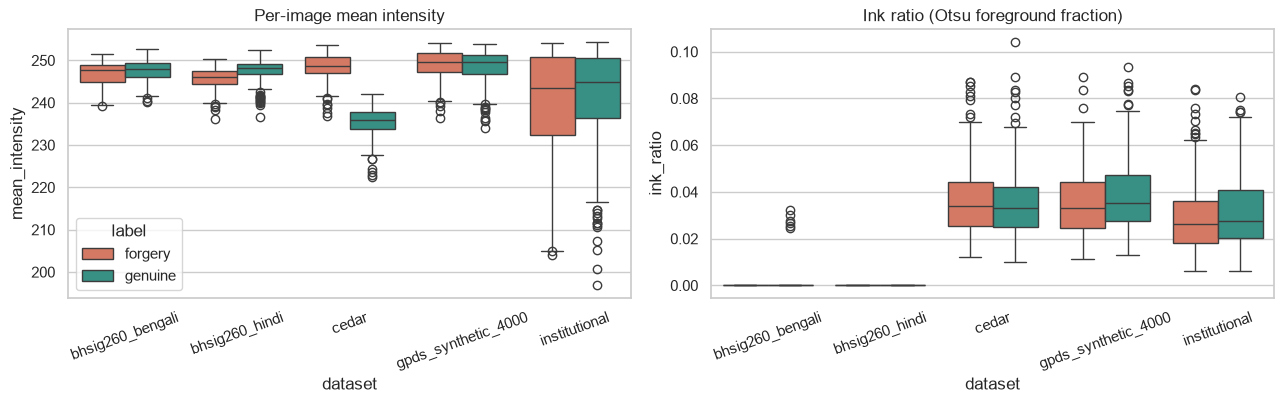

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
sns.boxplot(data=intensity_stats, x="dataset", y="mean_intensity",
            hue="label", palette={"genuine": "#2a9d8f", "forgery": "#e76f51"},
            ax=axes[0])
axes[0].set_title("Per-image mean intensity")
axes[0].tick_params(axis="x", rotation=20)
sns.boxplot(data=intensity_stats, x="dataset", y="ink_ratio",
            hue="label", palette={"genuine": "#2a9d8f", "forgery": "#e76f51"},
            ax=axes[1], legend=False)
axes[1].set_title("Ink ratio (Otsu foreground fraction)")
axes[1].tick_params(axis="x", rotation=20)
fig.tight_layout()
savefig(fig, "intensity_and_ink_ratio_boxplots")
plt.show()

intensity_stats.groupby(["dataset", "label"], observed=True)[
    ["mean_intensity", "std_intensity", "ink_ratio"]
].median().round(2).to_csv(TABLE_DIR / "eda_intensity_summary.csv")

## EDA takeaways checklist

- [ ] Class counts match the verified inventory (CEDAR 24G/24F,
      BHSig260 24G/30F, GPDS 24G/30F, institutional 12G/16F per writer)
- [ ] BHSig260-Hindi writer 123 appears in the ID-mismatch table only —
      folder-based labels remain correct
- [ ] No corrupted/empty images, or all are logged for exclusion
- [ ] Dimension/aspect spread → decide canonical input size + pad strategy
- [ ] Color modes → confirm grayscale conversion is safe everywhere
- [ ] Intensity histograms → check for class-conditional acquisition
      artifacts that preprocessing must neutralize